## Import libs

In [1]:
from tensorflow.python.data import Dataset
from sklearn.model_selection import train_test_split
import seaborn as sns
import pandas as pd


from falsb4mpa.dataset.load_data import load_data
from falsb4mpa.evaluation.evaluation import compute_predictive_metrics, compute_fair_metrics, compute_tradeoff, compute_intersectional_fair_metrics
from falsb4mpa.modeling.sk_vanilla.vanilla_lr import VanillaLogisticRegression

## Preliminaries

In [2]:
batch_size = 64
epochs = 100
learning_rate = 0.001

In [3]:
# cv_seeds = [13]
cv_seeds = [13, 29, 42, 55, 73]

## Load data

In [4]:
data_name = 'compas-mpa-bin-wout-agg'

In [5]:
x, y, a1, a2 = load_data(data_name)
raw_data = (x, y, a1, a2)

In [6]:
xdim = x.shape[1]
ydim = y.shape[1]
a1dim = a1.shape[1]
a2dim = a2.shape[1]
zdim = 8
print(xdim, ydim, a1dim, a2dim, zdim)

11 1 1 1 8


## Result file

In [7]:
header = [
    "model_name", "cv_seed", 
    "clas_acc", "f1-micro", "f1-macro",
    "a1_dp", "a1_deqodds", "a1_deqopp", 
    "a1_TN_g0", "a1_FP_g0", "a1_FN_g0", "a1_TP_g0", "a1_TN_g1", "a1_FP_g1", "a1_FN_g1", "a1_TP_g1", 
    "a2_dp", "a2_deqodds", "a2_deqopp", 
    "a2_TN_g0", "a2_FP_g0", "a2_FN_g0", "a2_TP_g0", "a2_TN_g1", "a2_FP_g1", "a2_FN_g1", "a2_TP_g1",
    "wc_spd", "wc_aod", "wc_eod"
]

results = []

## Testing

In [8]:
results= []
for cv_seed in cv_seeds:
        x_train, x_test, y_train, y_test, a1_train, a1_test, a2_train, a2_test = train_test_split(
                x, y, a1, a2, test_size=0.3, random_state=cv_seed
        )
        y_train = y_train.ravel()
        y_test = y_test.ravel()
        
        model = VanillaLogisticRegression(epochs, learning_rate)

        train_data = Dataset.from_tensor_slices((x_train, y_train, a1_train, a2_train))
        train_data = train_data.batch(batch_size, drop_remainder=True)

        test_data = Dataset.from_tensor_slices((x_test, y_test, a1_test, a2_test))
        test_data = test_data.batch(batch_size, drop_remainder=True)

        for epoch in range(epochs):
                for X, Y, A1, A2 in train_data:
                        model.partial_fit(X, Y)

         
        Y_hat = model.predict(x_test)

        clas_acc, clas_f1_micro, clas_f1_macro, confusion_matrix = compute_predictive_metrics(y_test, Y_hat)
        
        a1_dp, a1_deqodds, a1_deqopp, a1_metrics_g0, a1_metrics_g1 = compute_fair_metrics(y_test, a1_test, Y_hat, a1dim)
        a2_dp, a2_deqodds, a2_deqopp, a2_metrics_g0, a2_metrics_g1 = compute_fair_metrics(y_test, a2_test, Y_hat, a2dim)

        wc_spd, wc_aod, wc_eod = compute_intersectional_fair_metrics(y_test, a1_test, a2_test, Y_hat, a1dim, a2dim)
        
        # fair_metrics = (dp, deqodds, deqopp)
        
        # tradeoff = []
        
        # for fair_metric in fair_metrics:
        #         tradeoff.append(compute_tradeoff(clas_acc, fair_metric))
        
        # result = ['UnfairLR-decay', cv_seed, clas_acc, dp, deqodds, deqopp, tradeoff[0], tradeoff[1], tradeoff[2]]

        result = ['SkVanillaLR', cv_seed]
        result += [clas_acc, clas_f1_micro, clas_f1_macro]
        result += [a1_dp, a1_deqodds, a1_deqopp] + a1_metrics_g0 + a1_metrics_g1 
        result += [a2_dp, a2_deqodds, a2_deqopp] + a2_metrics_g0 + a2_metrics_g1
        result += [wc_spd, wc_aod, wc_eod]

        results.append(result)
        

2026-05-15 12:20:29.013407: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-15 12:20:29.026650: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-15 12:20:29.051560: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-15 12:20:29.099529: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-15 12:20:29.198258: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-15 12:20:29.401650: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-15 12:20:29.821060: I tensorflow/core/framework/local_rendezvous.cc:405] L

> Predictive Performance Evaluation
> Class Acc = 0.7852193713188171
> Confusion Matrix 
TN: 1474.0 | FP: 105.0 
FN: 360.0 | TP: 226.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.8937069773674011 | 0.8882064819335938 | 0.8269897699356079
> Confusion Matrix for A = 0 
TN: 1121.0 | FP: 95.0 
FN: 293.0 | TP: 205.0
> Confusion Matrix for A = 1 
TN: 353.0 | FP: 10.0 
FN: 67.0 | TP: 21.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.8179677724838257 | 0.7981797456741333 | 0.6798103451728821
> Confusion Matrix for A = 0 
TN: 614.0 | FP: 10.0 
FN: 97.0 | TP: 14.0
> Confusion Matrix for A = 1 
TN: 860.0 | FP: 95.0 
FN: 263.0 | TP: 212.0
> Intersectional Fairness Evaluation
> WC_SPD | WC_AOD | WC_EOD
> 0.7858073711395264 | 0.7778186202049255 | 0.650602400302887


2026-05-15 12:20:30.730642: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


> Predictive Performance Evaluation
> Class Acc = 0.7769052982330322
> Confusion Matrix 
TN: 1458.0 | FP: 106.0 
FN: 377.0 | TP: 224.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.8889359831809998 | 0.8567705750465393 | 0.755023717880249
> Confusion Matrix for A = 0 
TN: 1152.0 | FP: 95.0 
FN: 305.0 | TP: 210.0
> Confusion Matrix for A = 1 
TN: 306.0 | FP: 11.0 
FN: 72.0 | TP: 14.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.8102346658706665 | 0.7982531785964966 | 0.6923785209655762
> Confusion Matrix for A = 0 
TN: 611.0 | FP: 6.0 
FN: 95.0 | TP: 13.0
> Confusion Matrix for A = 1 
TN: 847.0 | FP: 100.0 
FN: 282.0 | TP: 211.0
> Intersectional Fairness Evaluation
> WC_SPD | WC_AOD | WC_EOD
> 0.7674538493156433 | 0.735804557800293 | 0.5862997770309448


2026-05-15 12:20:32.410899: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


> Predictive Performance Evaluation
> Class Acc = 0.7722863554954529
> Confusion Matrix 
TN: 1460.0 | FP: 116.0 
FN: 377.0 | TP: 212.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.8885077238082886 | 0.8697513937950134 | 0.7860721349716187
> Confusion Matrix for A = 0 
TN: 1145.0 | FP: 104.0 
FN: 319.0 | TP: 200.0
> Confusion Matrix for A = 1 
TN: 315.0 | FP: 12.0 
FN: 58.0 | TP: 12.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.8129397630691528 | 0.778807520866394 | 0.6494190692901611
> Confusion Matrix for A = 0 
TN: 607.0 | FP: 11.0 
FN: 112.0 | TP: 10.0
> Confusion Matrix for A = 1 
TN: 853.0 | FP: 105.0 
FN: 265.0 | TP: 202.0
> Intersectional Fairness Evaluation
> WC_SPD | WC_AOD | WC_EOD
> 0.7784500122070312 | 0.7522836923599243 | 0.6196638941764832


/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


> Predictive Performance Evaluation
> Class Acc = 0.7819861173629761
> Confusion Matrix 
TN: 1459.0 | FP: 98.0 
FN: 374.0 | TP: 234.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.8763023018836975 | 0.840061366558075 | 0.7227272391319275
> Confusion Matrix for A = 0 
TN: 1131.0 | FP: 88.0 
FN: 299.0 | TP: 221.0
> Confusion Matrix for A = 1 
TN: 328.0 | FP: 10.0 
FN: 75.0 | TP: 13.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.8300321102142334 | 0.8242023587226868 | 0.7199910283088684
> Confusion Matrix for A = 0 
TN: 621.0 | FP: 13.0 
FN: 100.0 | TP: 19.0
> Confusion Matrix for A = 1 
TN: 838.0 | FP: 85.0 
FN: 274.0 | TP: 215.0
> Intersectional Fairness Evaluation
> WC_SPD | WC_AOD | WC_EOD
> 0.7757534980773926 | 0.7468886375427246 | 0.5913683772087097
> Predictive Performance Evaluation
> Class Acc = 0.7709006667137146
> Confusion Matrix 
TN: 1449.0 | FP: 153.0 
FN: 343.0 | TP: 220.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.884653627872467 | 0.8831971883773804 | 0.83

/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [9]:
print(clas_acc, clas_f1_micro, clas_f1_macro)

0.77090067 0.7709006928406467 0.6619726112949449


<Axes: >

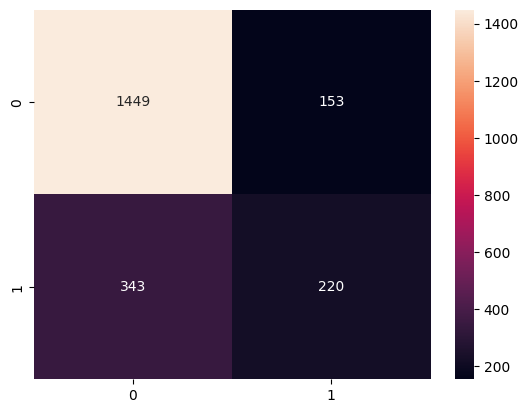

In [10]:
sns.heatmap(confusion_matrix, annot=True, fmt='g')

## Saving into DF then CSV

In [11]:
result_df = pd.DataFrame(results, columns=header)
result_df

,model_name,cv_seed,clas_acc,f1-micro,f1-macro,a1_dp,a1_deqodds,a1_deqopp,a1_TN_g0,a1_FP_g0,...,a2_FP_g0,a2_FN_g0,a2_TP_g0,a2_TN_g1,a2_FP_g1,a2_FN_g1,a2_TP_g1,wc_spd,wc_aod,wc_eod
0,SkVanillaLR,13,0.785219,0.785219,0.678334,0.893707,0.888206,0.826990,1121.0,95.0,...,10.0,97.0,14.0,860.0,95.0,263.0,212.0,0.785807,0.777819,0.650602
1,SkVanillaLR,29,0.776905,0.776905,0.669551,0.888936,0.856771,0.755024,1152.0,95.0,...,6.0,95.0,13.0,847.0,100.0,282.0,211.0,0.767454,0.735805,0.586300
2,SkVanillaLR,42,0.772286,0.772286,0.658965,0.888508,0.869751,0.786072,1145.0,104.0,...,11.0,112.0,10.0,853.0,105.0,265.0,202.0,0.778450,0.752284,0.619664
3,SkVanillaLR,55,0.781986,0.781986,0.679320,0.876302,0.840061,0.722727,1131.0,88.0,...,13.0,100.0,19.0,838.0,85.0,274.0,215.0,0.775753,0.746889,0.591368
4,SkVanillaLR,73,0.770901,0.770901,0.661973,0.884654,0.883197,0.837269,1131.0,140.0,...,10.0,97.0,16.0,830.0,143.0,246.0,204.0,0.762859,0.757638,0.668213


In [12]:
result_df.to_csv(f'../../results/{data_name}-vanilla_lr-{epochs}.csv')